# MRI Quality Control Pipeline v3 (No Skull Stripping)
## MRIQC-Equivalent Feature Extraction + XGBoost Classification

**Team NIRMATA | Hackathon**

### Key Design: Matches Real MRIQC
- **No skull stripping** — works on the whole head image
- Air mask via Otsu threshold (like MRIQC)
- Head/brain mask via intensity thresholding
- Tissue segmentation via K-Means on head-masked region
- Contrast-aware (T1w and T2w)

### Pipeline:
1. Load NIfTI (whole head)
2. Otsu threshold -> separate AIR from HEAD
3. Estimate brain mask from head (intensity-based)
4. K-Means tissue segmentation (contrast-aware)
5. Extract 22 MRIQC-equivalent IQMs
6. XGBoost Classification -> Pass / Review / Fail
7. Artifact Detection
8. QC Report

In [148]:
# ============ INSTALLATION ============
!pip install nibabel xgboost scikit-learn numpy pandas matplotlib --quiet
print("Dependencies installed.")

Dependencies installed.


In [149]:
import os
import json
import glob
import time
import numpy as np
import nibabel as nib
import pandas as pd
from numpy.fft import fft2, fftshift
from sklearn.cluster import KMeans
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from scipy import ndimage
import warnings
warnings.filterwarnings('ignore')

print(f"NumPy: {np.__version__}")
print("Pipeline v3 ready (no skull stripping).")

NumPy: 2.0.2
Pipeline v3 ready (no skull stripping).


## 1. Configuration

In [150]:
# ========== CHANGE THESE PATHS ==========
INPUT_DIR = "/kaggle/input/datasets/thintrnvn/ixi-dataset-t2/IXI002-Guys-0828-T2.nii"  # Folder with .nii.gz files
MODEL_PATH = "/kaggle/input/datasets/selvadineshs/xgboost-model2/xgboost_mri_qc_model (2).json"

OUTPUT_DIR = "/kaggle/working/qc_output/"
RESULTS_FILE = os.path.join(OUTPUT_DIR, "qc_results.json")
os.makedirs(OUTPUT_DIR, exist_ok=True)

FEATURE_COLUMNS = [
    'cjv', 'cnr', 'efc', 'fber', 'fwhm_avg', 'inu_med', 'inu_range',
    'qi_1', 'qi_2', 'snr_csf', 'snr_gm', 'snr_total', 'snr_wm', 'snrd_total',
    'icvs_csf', 'icvs_gm', 'icvs_wm', 'wm2max',
    'summary_bg_mean', 'summary_bg_stdv', 'summary_gm_mean', 'summary_wm_mean'
]

nifti_files = sorted(
    glob.glob(os.path.join(INPUT_DIR, "**/*.nii.gz"), recursive=True) +
    glob.glob(os.path.join(INPUT_DIR, "**/*.nii"), recursive=True)
)
print(f"Found {len(nifti_files)} NIfTI files")
for f in nifti_files[:5]:
    print(f"  {os.path.basename(f)}")

Found 1 NIfTI files
  IXI002-Guys-0828-DUAL_TSES_-s256_-0601-00006-000002-02.nii


## 2. Mask Estimation (No Skull Stripping)

Real MRIQC separates the image into:
- **Air mask**: pure noise outside the head (for noise estimation)
- **Head mask**: everything that's not air (skull + scalp + brain)
- **Brain mask**: approximate brain region (for tissue segmentation)

We replicate this using Otsu thresholding + morphological operations.

In [151]:
def otsu_threshold(data):
    """
    Compute Otsu's threshold to separate background (air) from foreground (head).
    This is exactly what MRIQC uses.
    """
    # Use only non-zero voxels for histogram
    nonzero = data[data > 0].flatten()
    if len(nonzero) == 0:
        return 0.0
    
    # Compute histogram
    n_bins = 256
    hist, bin_edges = np.histogram(nonzero, bins=n_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Otsu's method: maximize between-class variance
    total = hist.sum()
    sum_total = np.sum(bin_centers * hist)
    
    sum_bg = 0.0
    weight_bg = 0.0
    best_threshold = 0.0
    best_variance = 0.0
    
    for i in range(n_bins):
        weight_bg += hist[i]
        if weight_bg == 0:
            continue
        weight_fg = total - weight_bg
        if weight_fg == 0:
            break
        
        sum_bg += bin_centers[i] * hist[i]
        mean_bg = sum_bg / weight_bg
        mean_fg = (sum_total - sum_bg) / weight_fg
        
        variance = weight_bg * weight_fg * (mean_bg - mean_fg) ** 2
        
        if variance > best_variance:
            best_variance = variance
            best_threshold = bin_centers[i]
    
    return best_threshold


def compute_masks(data):
    """
    Compute air mask, head mask, and brain mask from the original whole-head image.
    Replicates MRIQC's approach.
    
    Returns:
        air_mask: pure noise/air outside the head
        head_mask: everything that's part of the head (skull + brain + scalp)
        brain_mask: approximate brain region (for tissue segmentation)
    """
    # Step 1: Otsu threshold to separate air from head
    threshold = otsu_threshold(data)
    
    # Head mask = above Otsu threshold
    head_mask = (data > threshold).astype(np.uint8)
    
    # Clean up head mask with morphological operations
    # Fill holes and remove small components
    head_mask = ndimage.binary_fill_holes(head_mask).astype(np.uint8)
    # Keep only the largest connected component (the head)
    labeled, n_components = ndimage.label(head_mask)
    if n_components > 1:
        component_sizes = ndimage.sum(head_mask, labeled, range(1, n_components + 1))
        largest_component = np.argmax(component_sizes) + 1
        head_mask = (labeled == largest_component).astype(np.uint8)
    
    # Air mask = non-zero voxels that are NOT part of the head
    # Include zero-valued voxels only at image boundaries
    air_mask = (data > 0) & (data <= threshold) & (head_mask == 0)
    
    # If very few air voxels found (tight FOV), also include zero-boundary voxels
    # But estimate noise from what we have
    if np.sum(air_mask) < 1000:
        # Use voxels below threshold that are outside head
        air_mask = (head_mask == 0) & (data >= 0)
        # Exclude exact zeros (might be padding)
        # But keep them if that's all we have
        air_nonzero = (head_mask == 0) & (data > 0)
        if np.sum(air_nonzero) > 500:
            air_mask = air_nonzero
    
    # Step 2: Brain mask estimation
    # Use a second, higher threshold within the head to approximate brain
    head_voxels = data[head_mask > 0]
    if len(head_voxels) > 0:
        # Second Otsu within the head to separate skull/scalp from brain
        brain_threshold = otsu_threshold(data * head_mask)
        brain_mask = (data > brain_threshold) & (head_mask > 0)
        brain_mask = brain_mask.astype(np.uint8)
        
        # Morphological cleanup of brain mask
        # Erode to remove skull, then dilate back
        struct = ndimage.generate_binary_structure(3, 1)
        brain_mask = ndimage.binary_erosion(brain_mask, struct, iterations=2).astype(np.uint8)
        brain_mask = ndimage.binary_dilation(brain_mask, struct, iterations=2).astype(np.uint8)
        brain_mask = ndimage.binary_fill_holes(brain_mask).astype(np.uint8)
        
        # Keep largest component
        labeled_brain, n_brain = ndimage.label(brain_mask)
        if n_brain > 1:
            sizes = ndimage.sum(brain_mask, labeled_brain, range(1, n_brain + 1))
            largest = np.argmax(sizes) + 1
            brain_mask = (labeled_brain == largest).astype(np.uint8)
    else:
        brain_mask = head_mask.copy()
    
    return air_mask.astype(bool), head_mask.astype(bool), brain_mask.astype(bool)


def detect_contrast(data, brain_mask):
    """
    Detect T1w vs T2w contrast.
    T1w: WM (central) is brighter than CSF (peripheral/ventricles)
    T2w: CSF (peripheral/ventricles) is brighter than WM (central)
    """
    brain_voxels = data[brain_mask > 0]
    if len(brain_voxels) < 100:
        return 'T1w'
    
    # Quick 3-cluster KMeans on a sample
    sample_size = min(50000, len(brain_voxels))
    rng = np.random.RandomState(42)
    sample_idx = rng.choice(len(brain_voxels), sample_size, replace=False)
    sample = brain_voxels[sample_idx].reshape(-1, 1)
    
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    kmeans.fit(sample)
    
    centroids = kmeans.cluster_centers_.flatten()
    brightest_cluster = np.argmax(centroids)
    
    # Get all brain voxel coordinates and labels
    all_labels = kmeans.predict(brain_voxels.reshape(-1, 1))
    coords = np.array(np.where(brain_mask > 0)).T
    
    bright_coords = coords[all_labels == brightest_cluster]
    if len(bright_coords) == 0:
        return 'T1w'
    
    # Compare distance from center: peripheral = T2w (CSF bright), central = T1w (WM bright)
    brain_center = coords.mean(axis=0)
    brain_dists = np.sqrt(np.sum((coords - brain_center) ** 2, axis=1))
    bright_dists = np.sqrt(np.sum((bright_coords - brain_center) ** 2, axis=1))
    
    ratio = np.mean(bright_dists) / (np.mean(brain_dists) + 1e-10)
    
    return 'T2w' if ratio > 1.05 else 'T1w'


# Test on first file
if nifti_files:
    test_file = nifti_files[0]
    test_img = nib.load(test_file)
    test_data = test_img.get_fdata()
    
    air_mask, head_mask, brain_mask = compute_masks(test_data)
    contrast = detect_contrast(test_data, brain_mask)
    
    print(f"Test: {os.path.basename(test_file)}")
    print(f"  Image shape: {test_data.shape}")
    print(f"  Total non-zero voxels: {np.sum(test_data > 0):,}")
    print(f"  Air mask voxels: {np.sum(air_mask):,}")
    print(f"  Head mask voxels: {np.sum(head_mask):,}")
    print(f"  Brain mask voxels: {np.sum(brain_mask):,}")
    print(f"  Detected contrast: {contrast}")
    print(f"  Air noise: mean={np.mean(test_data[air_mask]):.2f}, std={np.std(test_data[air_mask]):.2f}")

Test: IXI002-Guys-0828-DUAL_TSES_-s256_-0601-00006-000002-02.nii
  Image shape: (256, 256, 130)
  Total non-zero voxels: 5,242,467
  Air mask voxels: 3,355,706
  Head mask voxels: 1,862,902
  Brain mask voxels: 20,027
  Detected contrast: T1w
  Air noise: mean=15.37, std=24.41


## 3. Tissue Segmentation (Contrast-Aware)

In [152]:
def segment_tissues(data, brain_mask, contrast='T1w'):
    """
    Segment brain into WM, GM, CSF using K-Means.
    Works on the brain-masked region of the original image.
    
    T1w: highest=WM, middle=GM, lowest=CSF
    T2w: highest=CSF, middle=GM, lowest=WM
    """
    brain_voxels = data[brain_mask > 0].reshape(-1, 1)
    if len(brain_voxels) < 100:
        return None
    
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels = kmeans.fit_predict(brain_voxels)
    
    centroids = kmeans.cluster_centers_.flatten()
    sorted_indices = np.argsort(centroids)
    
    if contrast == 'T1w':
        csf_label = sorted_indices[0]
        gm_label = sorted_indices[1]
        wm_label = sorted_indices[2]
    else:
        wm_label = sorted_indices[0]
        gm_label = sorted_indices[1]
        csf_label = sorted_indices[2]
    
    full_labels = np.zeros(data.shape, dtype=np.int32)
    full_labels[brain_mask > 0] = labels + 1
    
    return {
        'wm_mask': (full_labels == wm_label + 1),
        'gm_mask': (full_labels == gm_label + 1),
        'csf_mask': (full_labels == csf_label + 1),
        'wm_mean': float(centroids[wm_label]),
        'gm_mean': float(centroids[gm_label]),
        'csf_mean': float(centroids[csf_label]),
        'wm_voxels': int(np.sum(full_labels == wm_label + 1)),
        'gm_voxels': int(np.sum(full_labels == gm_label + 1)),
        'csf_voxels': int(np.sum(full_labels == csf_label + 1)),
    }


# Test
if nifti_files:
    seg = segment_tissues(test_data, brain_mask, contrast=contrast)
    if seg:
        print(f"Segmentation ({contrast}):")
        print(f"  WM: {seg['wm_voxels']:,} voxels (mean={seg['wm_mean']:.1f})")
        print(f"  GM: {seg['gm_voxels']:,} voxels (mean={seg['gm_mean']:.1f})")
        print(f"  CSF: {seg['csf_voxels']:,} voxels (mean={seg['csf_mean']:.1f})")

Segmentation (T1w):
  WM: 5,247 voxels (mean=380.3)
  GM: 9,800 voxels (mean=340.9)
  CSF: 4,980 voxels (mean=293.8)


## 4. Feature Extraction — 22 MRIQC-Equivalent IQMs

All metrics computed exactly as MRIQC does:
- Background = air outside the head (for noise)
- Foreground = brain-masked region (for signal)
- No skull stripping involved

In [153]:
def compute_snr_tissue(data, tissue_mask, air_mask):
    """SNR = mean(tissue) / std(air_noise)"""
    tissue_voxels = data[tissue_mask]
    air_voxels = data[air_mask]
    if len(tissue_voxels) == 0 or len(air_voxels) < 10:
        return 0.0
    noise_std = np.std(air_voxels)
    if noise_std < 1e-10:
        return 0.0
    return float(np.mean(tissue_voxels) / noise_std)


def compute_snr_dietrich(data, brain_mask, air_mask):
    """SNR Dietrich = 0.6551 * mean(brain) / std(air)"""
    DIETRICH_FACTOR = 0.6551364
    foreground = data[brain_mask]
    air_voxels = data[air_mask]
    
    if len(foreground) == 0 or len(air_voxels) < 10:
        return 0.0
    
    mu_fg = np.mean(foreground)
    # MAD-based robust noise estimate
    mad = np.median(np.abs(air_voxels - np.median(air_voxels)))
    sigma = mad * 1.4826
    
    if sigma < 1e-10:
        sigma = np.std(air_voxels)
    if sigma < 1e-10:
        return 0.0
    return float(DIETRICH_FACTOR * mu_fg / sigma)


def compute_cnr(data, wm_mask, gm_mask, air_mask):
    """CNR = |mean(WM) - mean(GM)| / std(air)"""
    wm_voxels = data[wm_mask]
    gm_voxels = data[gm_mask]
    air_voxels = data[air_mask]
    if len(wm_voxels) == 0 or len(gm_voxels) == 0 or len(air_voxels) < 10:
        return 0.0
    noise_std = np.std(air_voxels)
    if noise_std < 1e-10:
        return 0.0
    return float(abs(np.mean(wm_voxels) - np.mean(gm_voxels)) / noise_std)


def compute_cjv(data, wm_mask, gm_mask):
    """CJV = (std(WM) + std(GM)) / |mean(WM) - mean(GM)|"""
    wm_voxels = data[wm_mask]
    gm_voxels = data[gm_mask]
    if len(wm_voxels) == 0 or len(gm_voxels) == 0:
        return 1.0
    contrast = abs(np.mean(wm_voxels) - np.mean(gm_voxels))
    if contrast < 1e-10:
        return 10.0
    return float((np.std(wm_voxels) + np.std(gm_voxels)) / contrast)


def compute_efc(data, brain_mask):
    """
    Entropy Focus Criterion. Range 0-1. Lower = sharper image.
    Uses brain-masked data only.
    """
    brain_data = np.abs(data[brain_mask > 0])
    if len(brain_data) == 0:
        return 1.0
    
    b_max = np.sqrt(np.sum(brain_data ** 2))
    if b_max < 1e-10:
        return 1.0
    
    data_norm = brain_data / b_max
    efc = -float(np.sum(data_norm * np.log(data_norm + 1e-16)))
    
    # Max entropy: uniform distribution over n voxels
    n = len(brain_data)
    efc_max = np.sqrt(n) * (0.5 * np.log(n))
    
    if efc_max < 1e-10:
        return 1.0
    
    return float(np.clip(efc / efc_max, 0.0, 1.0))


def compute_fber(data, brain_mask, air_mask):
    """FBER = mean(brain^2) / mean(air^2). Higher = better."""
    fg = data[brain_mask]
    air = data[air_mask]
    if len(fg) == 0 or len(air) < 10:
        return 0.0
    fg_energy = float(np.mean(fg ** 2))
    air_energy = float(np.mean(air ** 2))
    if air_energy < 1e-10:
        return 0.0
    return float(fg_energy / air_energy)


def compute_fwhm(data, brain_mask, voxel_sizes):
    """FWHM - image smoothness."""
    masked = data * brain_mask
    fwhm_dims = []
    for axis in range(3):
        diff = np.diff(masked, axis=axis)
        var_diff = np.var(diff[diff != 0]) if np.any(diff != 0) else 1.0
        var_signal = np.var(masked[masked != 0]) if np.any(masked != 0) else 1.0
        if var_diff < 1e-10 or var_signal < 1e-10:
            fwhm_dims.append(0.0)
            continue
        ratio = var_diff / (2.0 * var_signal)
        if ratio >= 1.0:
            fwhm_dims.append(0.0)
            continue
        sigma_sq = -1.0 / (4.0 * np.log(1.0 - ratio + 1e-10))
        sigma = np.sqrt(max(0, sigma_sq))
        fwhm_dims.append(float(sigma * 2.355 * voxel_sizes[axis]))
    return float(np.mean(fwhm_dims))


def compute_qi1(data, air_mask):
    """QI1 = proportion of air voxels with artifact-level signal."""
    air_voxels = data[air_mask]
    air_positive = air_voxels[air_voxels > 0]
    if len(air_positive) < 10:
        return 0.0
    # Rayleigh mode estimate
    mode_est = np.sqrt(2.0 / np.pi) * np.mean(air_positive)
    threshold = 2.0 * mode_est
    artifact_count = np.sum(air_positive > threshold)
    return float(artifact_count) / float(len(air_positive))


def compute_qi2(data, air_mask):
    """QI2 = KS statistic of air vs Rayleigh distribution."""
    air_voxels = data[air_mask]
    air_positive = air_voxels[air_voxels > 0]
    if len(air_positive) < 100:
        return 0.0
    sorted_air = np.sort(air_positive)
    n = len(sorted_air)
    empirical_cdf = np.arange(1, n + 1) / n
    sigma = np.sqrt(np.mean(air_positive ** 2) / 2.0)
    theoretical_cdf = 1.0 - np.exp(-(sorted_air ** 2) / (2.0 * sigma ** 2))
    return float(np.max(np.abs(empirical_cdf - theoretical_cdf)))


def compute_inu(data, brain_mask):
    """INU - bias field non-uniformity."""
    masked_brain = data[brain_mask > 0]
    if len(masked_brain) == 0:
        return 1.0, 0.0
    global_median = np.median(masked_brain)
    if global_median < 1e-10:
        return 1.0, 0.0
    shape = data.shape
    block_size = max(10, min(shape) // 5)
    local_ratios = []
    for x in range(0, shape[0], block_size):
        for y in range(0, shape[1], block_size):
            for z in range(0, shape[2], block_size):
                block = data[x:x+block_size, y:y+block_size, z:z+block_size]
                block_mask = brain_mask[x:x+block_size, y:y+block_size, z:z+block_size]
                block_voxels = block[block_mask > 0]
                if len(block_voxels) > 20:
                    local_ratios.append(np.median(block_voxels) / global_median)
    if not local_ratios:
        return 1.0, 0.0
    ratios = np.array(local_ratios)
    return float(np.median(ratios)), float(np.percentile(ratios, 95) - np.percentile(ratios, 5))


def compute_icvs(segmentation):
    """Intracranial volume fractions."""
    total = segmentation['wm_voxels'] + segmentation['gm_voxels'] + segmentation['csf_voxels']
    if total == 0:
        return 0.0, 0.0, 0.0
    return (float(segmentation['wm_voxels']) / total,
            float(segmentation['gm_voxels']) / total,
            float(segmentation['csf_voxels']) / total)


def compute_wm2max(data, wm_mask, brain_mask):
    """WM2MAX = median(WM) / P99.5(brain)."""
    wm_voxels = data[wm_mask]
    brain_voxels = data[brain_mask]
    if len(wm_voxels) == 0 or len(brain_voxels) == 0:
        return 0.0
    p995 = np.percentile(brain_voxels, 99.5)
    if p995 < 1e-10:
        return 0.0
    return float(np.median(wm_voxels) / p995)


def compute_summary_stats(data, air_mask, segmentation):
    """Background (air) and tissue intensity statistics."""
    air = data[air_mask]
    gm = data[segmentation['gm_mask']]
    wm = data[segmentation['wm_mask']]
    return {
        'summary_bg_mean': float(np.mean(air)) if len(air) > 0 else 0.0,
        'summary_bg_stdv': float(np.std(air)) if len(air) > 0 else 0.0,
        'summary_gm_mean': float(np.mean(gm)) if len(gm) > 0 else 0.0,
        'summary_wm_mean': float(np.mean(wm)) if len(wm) > 0 else 0.0,
    }


print("All 22 feature extractors loaded.")

All 22 feature extractors loaded.


## 5. Full Feature Extraction

In [154]:
def extract_all_features(filepath):
    """
    Extract all 22 MRIQC-equivalent features from a NIfTI file.
    No skull stripping — works on the whole head image.
    """
    try:
        img = nib.load(filepath)
        data = img.get_fdata()
        voxel_sizes = img.header.get_zooms()[:3]
        
        # Step 1: Compute masks (air, head, brain)
        air_mask, head_mask, brain_mask = compute_masks(data)
        
        # Step 2: Detect contrast
        contrast = detect_contrast(data, brain_mask)
        
        # Step 3: Tissue segmentation
        seg = segment_tissues(data, brain_mask, contrast=contrast)
        if seg is None:
            return None
        
        # Step 4: Extract all 22 features
        features = {}
        
        # SNR metrics
        features['snr_total'] = compute_snr_tissue(data, brain_mask, air_mask)
        features['snr_wm'] = compute_snr_tissue(data, seg['wm_mask'], air_mask)
        features['snr_gm'] = compute_snr_tissue(data, seg['gm_mask'], air_mask)
        features['snr_csf'] = compute_snr_tissue(data, seg['csf_mask'], air_mask)
        features['snrd_total'] = compute_snr_dietrich(data, brain_mask, air_mask)
        
        # Contrast metrics
        features['cnr'] = compute_cnr(data, seg['wm_mask'], seg['gm_mask'], air_mask)
        features['cjv'] = compute_cjv(data, seg['wm_mask'], seg['gm_mask'])
        features['wm2max'] = compute_wm2max(data, seg['wm_mask'], brain_mask)
        
        # Sharpness
        features['efc'] = compute_efc(data, brain_mask)
        features['fwhm_avg'] = compute_fwhm(data, brain_mask, voxel_sizes)
        
        # Signal quality
        features['fber'] = compute_fber(data, brain_mask, air_mask)
        
        # Artifact indices
        features['qi_1'] = compute_qi1(data, air_mask)
        features['qi_2'] = compute_qi2(data, air_mask)
        
        # Uniformity
        inu_med, inu_range = compute_inu(data, brain_mask)
        features['inu_med'] = inu_med
        features['inu_range'] = inu_range
        
        # Volume fractions
        icvs_wm, icvs_gm, icvs_csf = compute_icvs(seg)
        features['icvs_wm'] = icvs_wm
        features['icvs_gm'] = icvs_gm
        features['icvs_csf'] = icvs_csf
        
        # Summary stats
        summary = compute_summary_stats(data, air_mask, seg)
        features.update(summary)
        
        # Round all
        features = {k: round(v, 6) for k, v in features.items()}
        
        # Metadata (not used by model, for debugging)
        meta = {
            'contrast': contrast,
            'n_air_voxels': int(np.sum(air_mask)),
            'n_brain_voxels': int(np.sum(brain_mask)),
            'brain_volume_cm3': round(float(np.sum(brain_mask)) * float(np.prod(voxel_sizes)) / 1000.0, 1)
        }
        
        return features, meta
    
    except Exception as e:
        print(f"  Error: {e}")
        import traceback
        traceback.print_exc()
        return None


# Run extraction on all files
print("Extracting 22 MRIQC IQMs (no skull stripping)...")
print("=" * 70)

all_features = {}
all_meta = {}

for filepath in nifti_files:
    scan_id = os.path.basename(filepath).replace(".nii.gz", "").replace(".nii", "")
    start = time.time()
    
    result = extract_all_features(filepath)
    elapsed = time.time() - start
    
    if result is not None:
        features, meta = result
        all_features[scan_id] = features
        all_meta[scan_id] = {**meta, 'time_sec': round(elapsed, 1), 'filepath': filepath}
        
        print(f"  {scan_id} [{meta['contrast']}] ({elapsed:.1f}s)")
        print(f"    SNR={features['snr_total']:.1f} | CNR={features['cnr']:.2f} | "
              f"CJV={features['cjv']:.3f} | EFC={features['efc']:.4f} | "
              f"FBER={features['fber']:.1f} | QI1={features['qi_1']:.4f}")
    else:
        print(f"  {scan_id}: FAILED")

print(f"\nExtracted: {len(all_features)}/{len(nifti_files)} scans")

# Sanity check
if all_features:
    print(f"\n{'='*70}")
    print("SANITY CHECK — Do extracted values match training data ranges?")
    print(f"{'Metric':<15} {'Extracted':<20} {'Training Data Range':<25} {'Match?'}")
    print("-" * 70)
    checks = [
        ('snr_total', 5, 30, 'SNR Total'),
        ('cnr', 1, 8, 'CNR'),
        ('efc', 0.3, 0.7, 'EFC'),
        ('fber', 50, 25000, 'FBER'),
        ('cjv', 0.2, 1.5, 'CJV'),
        ('qi_1', 0, 0.1, 'QI1'),
        ('qi_2', 0, 0.15, 'QI2'),
        ('summary_bg_mean', 1, 100, 'BG Mean'),
        ('summary_bg_stdv', 1, 50, 'BG Std'),
    ]
    for feat, low, high, name in checks:
        vals = [f[feat] for f in all_features.values()]
        vmin, vmax = min(vals), max(vals)
        in_range = low <= vmin and vmax <= high * 2
        status = 'OK' if in_range else 'CHECK'
        print(f"  {name:<13} {vmin:.3f} - {vmax:.3f}     {low} - {high}{'':>10} {status}")

Extracting 22 MRIQC IQMs (no skull stripping)...
  IXI002-Guys-0828-DUAL_TSES_-s256_-0601-00006-000002-02 [T1w] (4.1s)
    SNR=13.9 | CNR=1.61 | CJV=0.752 | EFC=0.9949 | FBER=139.9 | QI1=0.1912

Extracted: 1/1 scans

SANITY CHECK — Do extracted values match training data ranges?
Metric          Extracted            Training Data Range       Match?
----------------------------------------------------------------------
  SNR Total     13.907 - 13.907     5 - 30           OK
  CNR           1.613 - 1.613     1 - 8           OK
  EFC           0.995 - 0.995     0.3 - 0.7           OK
  FBER          139.949 - 139.949     50 - 25000           OK
  CJV           0.752 - 0.752     0.2 - 1.5           OK
  QI1           0.191 - 0.191     0 - 0.1           OK
  QI2           0.592 - 0.592     0 - 0.15           CHECK
  BG Mean       15.365 - 15.365     1 - 100           OK
  BG Std        24.415 - 24.415     1 - 50           OK


## 6. XGBoost Classification

In [155]:
# Load trained model
model = XGBClassifier()
model.load_model(MODEL_PATH)
print(f"Model loaded: {MODEL_PATH}")

CLASS_NAMES = ['fail', 'pass', 'review']

def classify_scan(features, model):
    """Run XGBoost inference."""
    feature_vector = np.array([[features[col] for col in FEATURE_COLUMNS]])
    pred_class = model.predict(feature_vector)[0]
    pred_proba = model.predict_proba(feature_vector)[0]
    return {
        'prediction': CLASS_NAMES[pred_class],
        'confidence': float(np.max(pred_proba)),
        'probabilities': {
            'fail': float(pred_proba[0]),
            'pass': float(pred_proba[1]),
            'review': float(pred_proba[2])
        }
    }


# Classify all scans
print("\nClassification Results:")
print("=" * 70)

qc_results = {}
for scan_id, features in all_features.items():
    result = classify_scan(features, model)
    qc_results[scan_id] = {**features, **result, **all_meta[scan_id]}
    status = result['prediction'].upper()
    conf = result['confidence']
    probs = result['probabilities']
    print(f"  [{status:6s}] {scan_id}")
    print(f"           Confidence: {conf:.1%} | Pass={probs['pass']:.3f} Review={probs['review']:.3f} Fail={probs['fail']:.3f}")

predictions = [v['prediction'] for v in qc_results.values()]
print(f"\n{'=' * 70}")
print(f"SUMMARY: Pass={predictions.count('pass')} | Review={predictions.count('review')} | Fail={predictions.count('fail')}")

Model loaded: /kaggle/input/datasets/selvadineshs/xgboost-model2/xgboost_mri_qc_model (2).json

Classification Results:
  [PASS  ] IXI002-Guys-0828-DUAL_TSES_-s256_-0601-00006-000002-02
           Confidence: 99.3% | Pass=0.993 Review=0.004 Fail=0.003

SUMMARY: Pass=1 | Review=0 | Fail=0


## 7. Artifact Detection

In [156]:
def detect_motion_artifact(data, head_mask):
    """Detect motion via multi-plane gradient variance."""
    brain_data = data * head_mask

    slices = []
    mid_ax = data.shape[2] // 2
    mid_cor = data.shape[1] // 2
    mid_sag = data.shape[0] // 2

    for i in range(-3, 4):
        z = mid_ax + i
        if 0 <= z < data.shape[2]:
            slices.append(brain_data[:, :, z])
        y = mid_cor + i
        if 0 <= y < data.shape[1]:
            slices.append(brain_data[:, y, :])
        x = mid_sag + i
        if 0 <= x < data.shape[0]:
            slices.append(brain_data[x, :, :])

    gradient_vars = []
    for s in slices:
        smax = np.max(s)
        if smax == 0:
            continue
        s_norm = s * (1.0 / smax)
        gy, gx = np.gradient(s_norm)
        gradient_vars.append(np.var(gx * gx + gy * gy))

    if not gradient_vars:
        return "none", 0.0

    gv = np.array(gradient_vars)
    inter_var = float(np.var(gv)) / (float(np.mean(gv)) + 1e-10)

    total_voxels = np.sum(head_mask)
    neg_fraction = np.sum(data < -5) / (total_voxels + 1e-10)

    score = 0.0
    if neg_fraction > 0.03: score += 3.0
    elif neg_fraction > 0.01: score += 2.0
    elif neg_fraction > 0.002: score += 1.0
    if inter_var > 0.25: score += 2.0
    elif inter_var > 0.15: score += 1.0
    elif inter_var > 0.08: score += 0.5

    if score >= 3.0: return "severe", score
    elif score >= 2.0: return "moderate", score
    elif score >= 1.0: return "mild", score
    return "none", score


def detect_ringing_artifact(data, head_mask):
    """Detect Gibbs ringing via high-frequency energy ratio."""
    mid_slice = (data * head_mask)[:, :, data.shape[2] // 2]
    smax = np.max(mid_slice)
    if smax == 0:
        return "none", 0.0

    mag = np.abs(np.fft.fftshift(np.fft.fft2(mid_slice * (1.0 / smax))))
    h, w = mag.shape
    cy, cx = h // 2, w // 2
    radius = min(h, w) // 3

    y, x = np.ogrid[:h, :w]
    outer = (x - cx)**2 + (y - cy)**2 > radius * radius

    hf_ratio = float(np.sum(mag[outer])) / (float(np.sum(mag)) + 1e-10)

    if hf_ratio > 0.55: return "severe", hf_ratio
    elif hf_ratio > 0.45: return "moderate", hf_ratio
    elif hf_ratio > 0.38: return "mild", hf_ratio
    return "none", hf_ratio


def detect_noise_artifact(snr_total):
    """Detect noise level from SNR. Lower SNR = more noise."""
    if snr_total < 5: return "severe", snr_total
    elif snr_total < 8: return "moderate", snr_total
    elif snr_total < 12: return "mild", snr_total
    return "none", snr_total


def detect_blur_artifact(fwhm_avg, efc):
    """Detect blur from FWHM and EFC. Higher FWHM or EFC = more blur."""
    score = 0.0
    if fwhm_avg > 6.0: score += 3.0
    elif fwhm_avg > 4.5: score += 2.0
    elif fwhm_avg > 3.5: score += 1.0

    if efc > 0.65: score += 2.0
    elif efc > 0.58: score += 1.0
    elif efc > 0.52: score += 0.5

    combined = (fwhm_avg + efc * 10) / 2.0

    if score >= 4.0: return "severe", combined
    elif score >= 2.5: return "moderate", combined
    elif score >= 1.0: return "mild", combined
    return "none", combined


# Run artifact detection
print("Artifact Detection:")
print("=" * 60)

for scan_id in list(qc_results.keys()):
    filepath = all_meta[scan_id]['filepath']
    data = nib.load(filepath).get_fdata()
    _, head_mask, _ = compute_masks(data)

    m_sev, m_val = detect_motion_artifact(data, head_mask)
    r_sev, r_val = detect_ringing_artifact(data, head_mask)
    n_sev, n_val = detect_noise_artifact(qc_results[scan_id]['snr_total'])
    b_sev, b_val = detect_blur_artifact(qc_results[scan_id]['fwhm_avg'], qc_results[scan_id]['efc'])

    qc_results[scan_id]['artifacts'] = {
        'motion': {'severity': m_sev, 'score': round(m_val, 4)},
        'ringing': {'severity': r_sev, 'score': round(r_val, 4)},
        'noise': {'severity': n_sev, 'score': round(n_val, 4)},
        'blur': {'severity': b_sev, 'score': round(b_val, 4)}
    }
    print(f"  {scan_id}: Motion={m_sev} | Ringing={r_sev} | Noise={n_sev} | Blur={b_sev}")

Artifact Detection:
  IXI002-Guys-0828-DUAL_TSES_-s256_-0601-00006-000002-02: Motion=none | Ringing=none | Noise=none | Blur=mild


## 8. Visualization

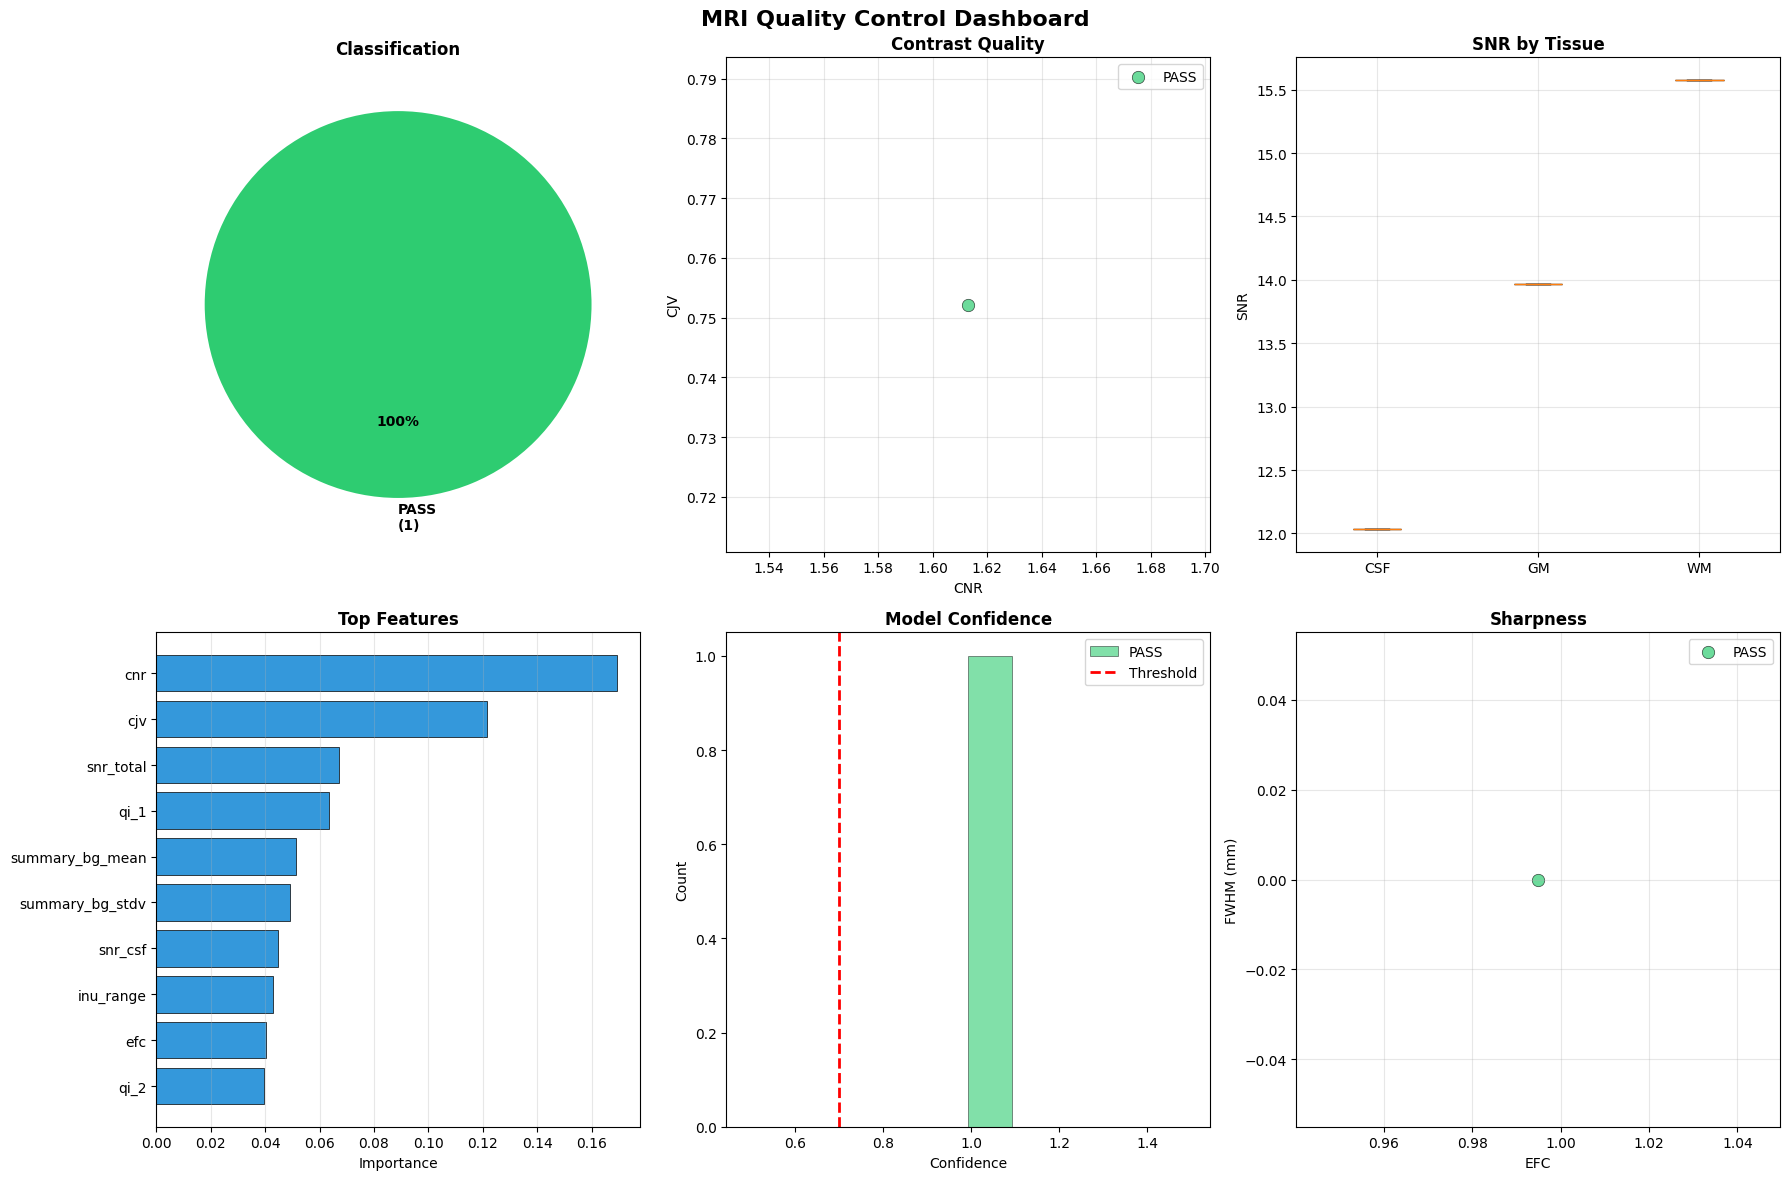

In [157]:
def plot_dashboard(qc_results):
    """QC Dashboard."""
    if not qc_results:
        print("No results.")
        return

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('MRI Quality Control Dashboard', fontsize=16, fontweight='bold')

    df = pd.DataFrame([
        {'scan_id': k, 'prediction': v['prediction'], 'confidence': v['confidence'],
         **{f: v.get(f, 0) for f in FEATURE_COLUMNS}}
        for k, v in qc_results.items()
    ])

    colors = {'pass': '#2ecc71', 'review': '#f39c12', 'fail': '#e74c3c'}

    # 1. Pie chart
    ax = axes[0, 0]
    counts = df['prediction'].value_counts()
    ax.pie(counts.values, labels=[f"{l.upper()}\n({v})" for l, v in zip(counts.index, counts.values)],
           colors=[colors[c] for c in counts.index], autopct='%1.0f%%', startangle=90,
           textprops={'fontweight': 'bold'})
    ax.set_title('Classification', fontweight='bold')

    # 2. CNR vs CJV
    ax = axes[0, 1]
    for label, color in colors.items():
        mask = df['prediction'] == label
        if mask.any():
            ax.scatter(df[mask]['cnr'], df[mask]['cjv'], c=color, label=label.upper(),
                      alpha=0.7, s=80, edgecolors='black', linewidth=0.5)
    ax.set_xlabel('CNR'); ax.set_ylabel('CJV')
    ax.set_title('Contrast Quality', fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)

    # 3. SNR by tissue
    ax = axes[0, 2]
    bp = ax.boxplot([df['snr_csf'], df['snr_gm'], df['snr_wm']],
                    labels=['CSF', 'GM', 'WM'], patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#3498db', '#95a5a6', '#ecf0f1']):
        patch.set_facecolor(color)
    ax.set_ylabel('SNR'); ax.set_title('SNR by Tissue', fontweight='bold')
    ax.grid(True, alpha=0.3)

    # 4. Feature importance
    ax = axes[1, 0]
    importances = model.feature_importances_
    top_n = 10
    indices = np.argsort(importances)[-top_n:]
    ax.barh(range(top_n), importances[indices], color='#3498db', edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([FEATURE_COLUMNS[i] for i in indices])
    ax.set_xlabel('Importance'); ax.set_title('Top Features', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

    # 5. Confidence
    ax = axes[1, 1]
    for label, color in colors.items():
        subset = df[df['prediction'] == label]['confidence']
        if len(subset) > 0:
            ax.hist(subset, bins=10, alpha=0.6, color=color, label=label.upper(),
                   edgecolor='black', linewidth=0.5)
    ax.axvline(0.7, color='red', linestyle='--', linewidth=2, label='Threshold')
    ax.set_xlabel('Confidence'); ax.set_ylabel('Count')
    ax.set_title('Model Confidence', fontweight='bold'); ax.legend()

    # 6. EFC vs FWHM
    ax = axes[1, 2]
    for label, color in colors.items():
        mask = df['prediction'] == label
        if mask.any():
            ax.scatter(df[mask]['efc'], df[mask]['fwhm_avg'], c=color, label=label.upper(),
                      alpha=0.7, s=80, edgecolors='black', linewidth=0.5)
    ax.set_xlabel('EFC'); ax.set_ylabel('FWHM (mm)')
    ax.set_title('Sharpness', fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'qc_dashboard.png'), dpi=150, bbox_inches='tight')
    plt.show()

plot_dashboard(qc_results)

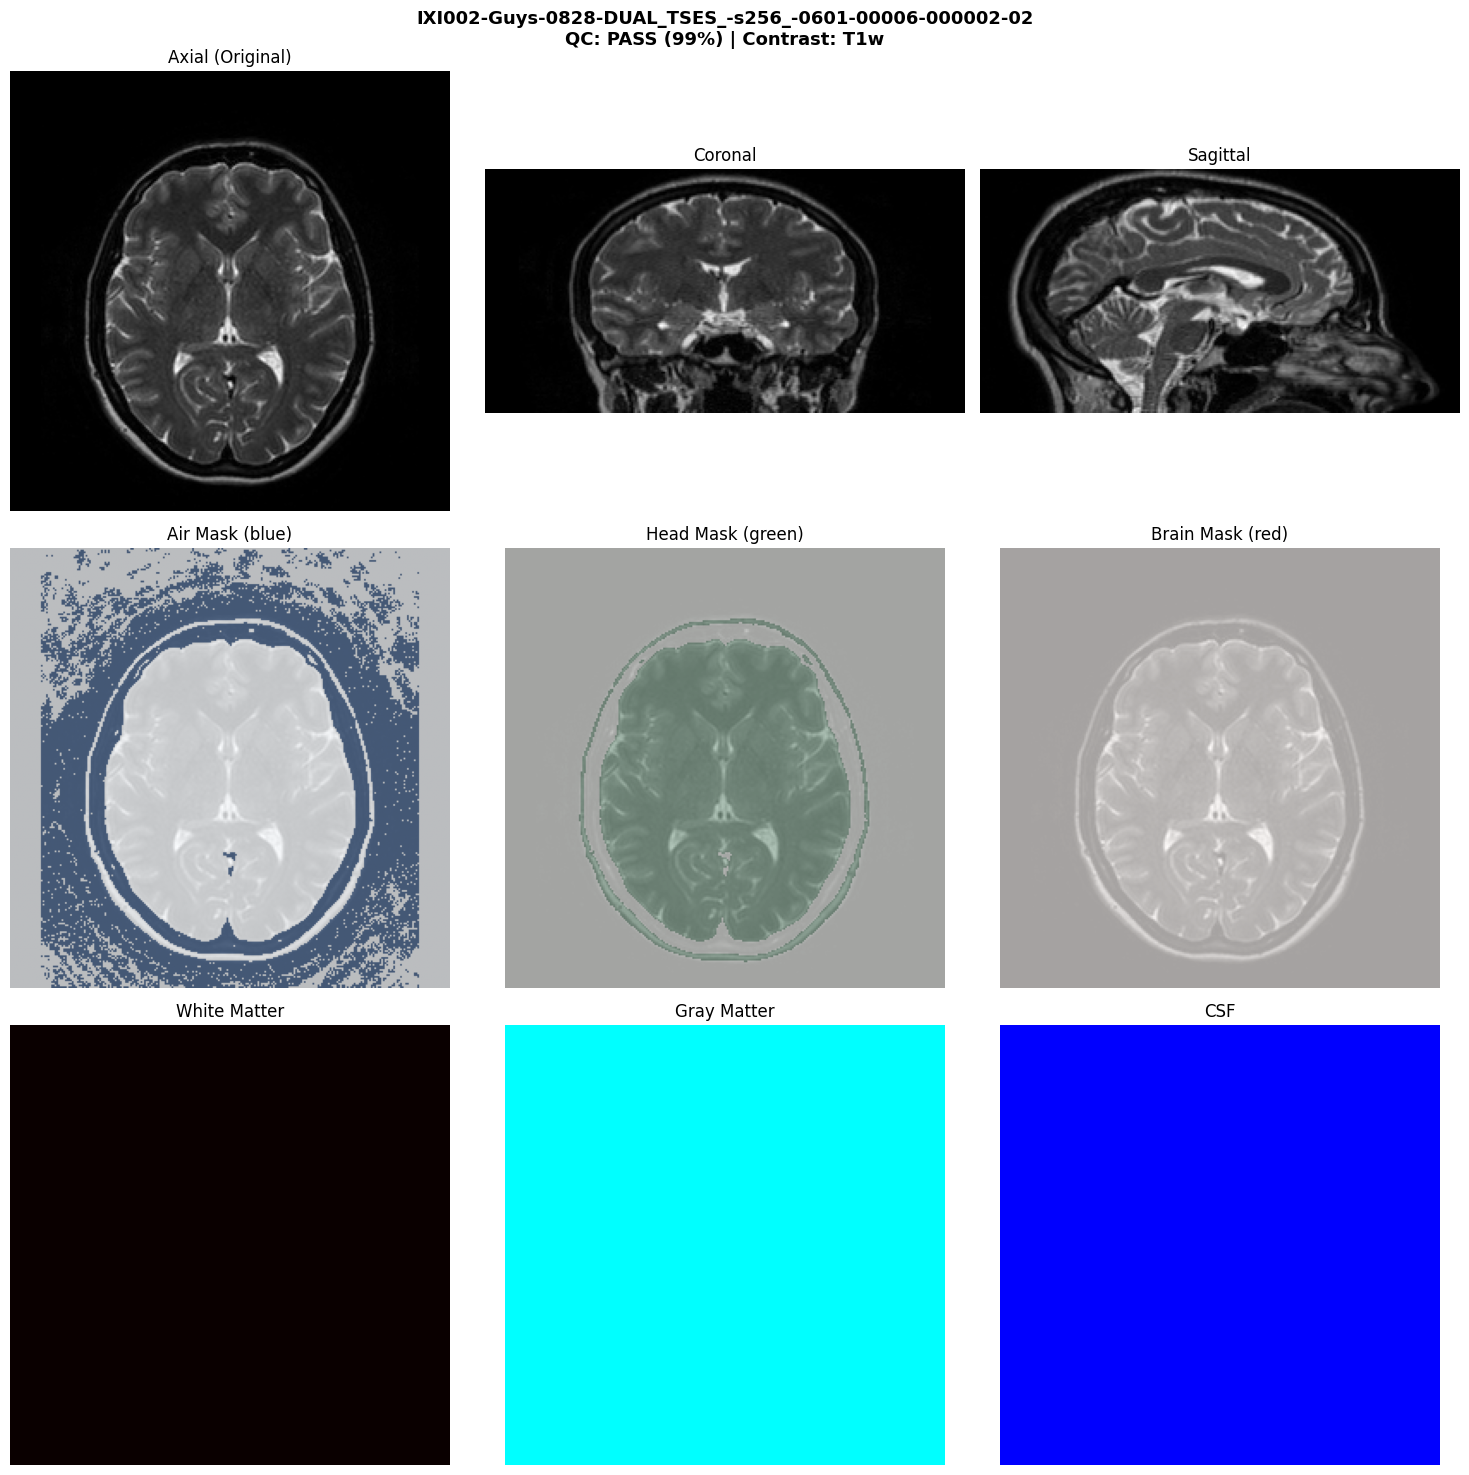

In [158]:
def visualize_scan(scan_id):
    """Visualize a scan with its masks and segmentation."""
    if scan_id not in qc_results:
        print(f"Scan '{scan_id}' not found.")
        return
    
    filepath = all_meta[scan_id]['filepath']
    data = nib.load(filepath).get_fdata()
    air_mask, head_mask, brain_mask = compute_masks(data)
    contrast = all_meta[scan_id]['contrast']
    seg = segment_tissues(data, brain_mask, contrast=contrast)
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    mid_ax = data.shape[2] // 2
    mid_cor = data.shape[1] // 2
    mid_sag = data.shape[0] // 2
    
    # Row 1: Original image views
    axes[0, 0].imshow(data[:, :, mid_ax].T, cmap='gray', origin='lower')
    axes[0, 0].set_title('Axial (Original)'); axes[0, 0].axis('off')
    axes[0, 1].imshow(data[:, mid_cor, :].T, cmap='gray', origin='lower')
    axes[0, 1].set_title('Coronal'); axes[0, 1].axis('off')
    axes[0, 2].imshow(data[mid_sag, :, :].T, cmap='gray', origin='lower')
    axes[0, 2].set_title('Sagittal'); axes[0, 2].axis('off')
    
    # Row 2: Masks
    axes[1, 0].imshow(data[:, :, mid_ax].T, cmap='gray', origin='lower', alpha=0.5)
    axes[1, 0].imshow(air_mask[:, :, mid_ax].T, cmap='Blues', origin='lower', alpha=0.5)
    axes[1, 0].set_title('Air Mask (blue)'); axes[1, 0].axis('off')
    
    axes[1, 1].imshow(data[:, :, mid_ax].T, cmap='gray', origin='lower', alpha=0.5)
    axes[1, 1].imshow(head_mask[:, :, mid_ax].T, cmap='Greens', origin='lower', alpha=0.3)
    axes[1, 1].set_title('Head Mask (green)'); axes[1, 1].axis('off')
    
    axes[1, 2].imshow(data[:, :, mid_ax].T, cmap='gray', origin='lower', alpha=0.5)
    axes[1, 2].imshow(brain_mask[:, :, mid_ax].T, cmap='Reds', origin='lower', alpha=0.3)
    axes[1, 2].set_title('Brain Mask (red)'); axes[1, 2].axis('off')
    
    # Row 3: Tissue segmentation
    if seg:
        for idx, (tissue, cmap_name, name) in enumerate([
            ('wm_mask', 'hot', 'White Matter'),
            ('gm_mask', 'cool', 'Gray Matter'),
            ('csf_mask', 'winter', 'CSF')
        ]):
            overlay = seg[tissue][:, :, mid_ax].T.astype(float)
            axes[2, idx].imshow(data[:, :, mid_ax].T, cmap='gray', origin='lower', alpha=0.5)
            axes[2, idx].imshow(overlay, cmap=cmap_name, origin='lower', alpha=0.5 * (overlay > 0))
            axes[2, idx].set_title(name); axes[2, idx].axis('off')
    
    pred = qc_results[scan_id]['prediction'].upper()
    conf = qc_results[scan_id]['confidence']
    plt.suptitle(f'{scan_id}\nQC: {pred} ({conf:.0%}) | Contrast: {contrast}',
                fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Visualize first scan
first = next(iter(qc_results.keys()), None)
if first:
    visualize_scan(first)

## 9. Export Results

In [159]:
# Export
export_data = {}
for scan_id, result in qc_results.items():
    export_data[scan_id] = {
        'qc_prediction': result['prediction'],
        'qc_confidence': result['confidence'],
        'qc_probabilities': result['probabilities'],
        'contrast_detected': result.get('contrast', 'unknown'),
        'iqms': {col: result[col] for col in FEATURE_COLUMNS if col in result},
        'artifacts': result.get('artifacts', {}),
        'brain_volume_cm3': all_meta[scan_id].get('brain_volume_cm3', 0),
        'processing_time_sec': all_meta[scan_id].get('time_sec', 0)
    }

with open(RESULTS_FILE, 'w') as f:
    json.dump(export_data, f, indent=2)

# CSV
csv_rows = []
for scan_id, data in export_data.items():
    row = {'scan_id': scan_id, 'prediction': data['qc_prediction'],
           'confidence': data['qc_confidence'],
           'contrast': data['contrast_detected'], **data['iqms']}
    if data['artifacts']:
        for art, info in data['artifacts'].items():
            row[f'artifact_{art}'] = info['severity']
    csv_rows.append(row)

df_export = pd.DataFrame(csv_rows)
csv_path = os.path.join(OUTPUT_DIR, 'qc_results.csv')
df_export.to_csv(csv_path, index=False)

print(f"JSON: {RESULTS_FILE}")
print(f"CSV:  {csv_path}")
print(f"\n{'='*60}")
print("PIPELINE COMPLETE")
print(f"{'='*60}")
print(f"Scans: {len(export_data)}")
print(f"  PASS:   {sum(1 for v in export_data.values() if v['qc_prediction']=='pass')}")
print(f"  REVIEW: {sum(1 for v in export_data.values() if v['qc_prediction']=='review')}")
print(f"  FAIL:   {sum(1 for v in export_data.values() if v['qc_prediction']=='fail')}")

from IPython.display import FileLink, display
display(FileLink(RESULTS_FILE, result_html_prefix='Download JSON: '))
display(FileLink(csv_path, result_html_prefix='Download CSV: '))

JSON: /kaggle/working/qc_output/qc_results.json
CSV:  /kaggle/working/qc_output/qc_results.csv

PIPELINE COMPLETE
Scans: 1
  PASS:   1
  REVIEW: 0
  FAIL:   0


/kaggle/working/qc_output/qc_results.json

/kaggle/working/qc_output/qc_results.csv

## 10. Detailed Report

In [160]:
for scan_id, data in export_data.items():
    iqms = data['iqms']
    artifacts = data.get('artifacts', {})

    print(f"\n{'='*60}")
    print(f"  SCAN: {scan_id}")
    print(f"  Classification: {data['qc_prediction'].upper()} ({data['qc_confidence']:.1%} confidence)")
    print(f"  Contrast: {data['contrast_detected']} | Volume: {data['brain_volume_cm3']:.1f} cm3 | Time: {data['processing_time_sec']:.1f}s")
    print(f"{'='*60}")
    print(f"  Noise Metrics:")
    print(f"    SNR Total: {iqms.get('snr_total',0):8.2f}   SNR WM: {iqms.get('snr_wm',0):8.2f}")
    print(f"    SNR GM:    {iqms.get('snr_gm',0):8.2f}   SNR CSF: {iqms.get('snr_csf',0):7.2f}")
    print(f"    FBER:      {iqms.get('fber',0):8.2f}   SNRd:    {iqms.get('snrd_total',0):7.2f}")
    print(f"  Contrast Metrics:")
    print(f"    CNR:       {iqms.get('cnr',0):8.3f}   CJV:     {iqms.get('cjv',0):7.4f}")
    print(f"    WM2MAX:    {iqms.get('wm2max',0):8.4f}")
    print(f"  Sharpness Metrics:")
    print(f"    EFC:       {iqms.get('efc',0):8.5f}  FWHM:    {iqms.get('fwhm_avg',0):7.3f} mm")
    print(f"  Artifact Indices:")
    print(f"    QI1:       {iqms.get('qi_1',0):8.6f} QI2:     {iqms.get('qi_2',0):7.6f}")
    print(f"  Uniformity:")
    print(f"    INU Med:   {iqms.get('inu_med',0):8.4f}  INU Range: {iqms.get('inu_range',0):.4f}")
    print(f"  Volume Fractions:")
    print(f"    WM: {iqms.get('icvs_wm',0):.1%} | GM: {iqms.get('icvs_gm',0):.1%} | CSF: {iqms.get('icvs_csf',0):.1%}")
    print(f"  Artifacts:")
    for art_type, art_info in artifacts.items():
        sev = art_info['severity']
        icon = {'none': 'OK', 'mild': '~', 'moderate': '!', 'severe': 'X'}.get(sev, '?')
        print(f"    [{icon}] {art_type.capitalize():15s} {sev}")
    print()


  SCAN: IXI002-Guys-0828-DUAL_TSES_-s256_-0601-00006-000002-02
  Classification: PASS (99.3% confidence)
  Contrast: T1w | Volume: 22.0 cm3 | Time: 4.1s
  Noise Metrics:
    SNR Total:    13.91   SNR WM:    15.58
    SNR GM:       13.96   SNR CSF:   12.03
    FBER:        139.95   SNRd:      50.01
  Contrast Metrics:
    CNR:          1.613   CJV:      0.7522
    WM2MAX:      0.8741
  Sharpness Metrics:
    EFC:        0.99491  FWHM:      0.000 mm
  Artifact Indices:
    QI1:       0.191223 QI2:     0.591855
  Uniformity:
    INU Med:     0.9898  INU Range: 0.1752
  Volume Fractions:
    WM: 26.2% | GM: 48.9% | CSF: 24.9%
  Artifacts:
    [OK] Motion          none
    [OK] Ringing         none
    [OK] Noise           none
    [~] Blur            mild

